# **Configurations**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import sys

from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/College/FLEX-Med/backend/federated_learning

# Dependency Installation
!pip install fastapi uvicorn pyngrok nest-asyncio flwr["simulation"] flwr_datasets datasets supabase -q

PROJECT_ROOT = "/content/drive/MyDrive/College/FLEX-Med/backend/federated_learning"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/College/FLEX-Med/backend/federated_learning


# **Verify if the environment is setup for FL simulation**

In [ ]:
#!/usr/bin/env python3
"""
FL Health Verification Script v3.0 (Jupyter / Colab Safe)

Updated for v3.0 architecture:
- Checks 3-folder dataset structure (anchor, test, local_train)
- Validates Dirichlet partitioning configuration
- Verifies num-supernodes matches client count in data.json
- No longer checks deprecated per-client dataset folders
"""

import os
import json
import re
import sys
from pathlib import Path
from typing import Dict, List, Tuple

# =====================================================
# PROJECT ROOT RESOLUTION (JUPYTER SAFE)
# =====================================================
PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# =====================================================
# ANSI COLORS
# =====================================================
class Colors:
    GREEN = '\033[92m'
    YELLOW = '\033[93m'
    RED = '\033[91m'
    BLUE = '\033[94m'
    BOLD = '\033[1m'
    END = '\033[0m'


def print_header(text: str):
    print(f"\n{Colors.BOLD}{Colors.BLUE}{'=' * 70}{Colors.END}")
    print(f"{Colors.BOLD}{Colors.BLUE}{text.center(70)}{Colors.END}")
    print(f"{Colors.BOLD}{Colors.BLUE}{'=' * 70}{Colors.END}\n")


def print_success(text: str):
    print(f"{Colors.GREEN}  {text}{Colors.END}")


def print_warning(text: str):
    print(f"{Colors.YELLOW}  {text}{Colors.END}")


def print_error(text: str):
    print(f"{Colors.RED}  {text}{Colors.END}")


def print_info(text: str):
    print(f"  {text}")


# =====================================================
# DATASET CHECK (v3.0: 3-folder structure)
# =====================================================
def check_dataset_structure(
    dataset_path: Path,
    expected_classes: List[str] = ["all", "hem"]
) -> Tuple[bool, Dict]:
    stats = {}

    if not dataset_path.exists():
        return False, {"error": f"Path does not exist: {dataset_path}"}

    for class_name in expected_classes:
        class_path = dataset_path / class_name
        if not class_path.exists():
            return False, {"error": f"Missing class directory: {class_name}"}

        image_exts = {'.jpg', '.jpeg', '.png', '.bmp'}
        images = [f for f in class_path.iterdir() if f.suffix.lower() in image_exts]
        stats[class_name] = len(images)

    total = sum(stats.values())
    if total == 0:
        return False, {"error": "No images found in dataset"}

    for cls in expected_classes:
        stats[f"{cls}_pct"] = stats[cls] / total * 100

    stats["total"] = total
    return True, stats


def verify_datasets(use_colab: bool = True) -> bool:
    print_header("Step 1: Dataset Structure (v3.0 - Dirichlet Partitioning)")

    if use_colab:
        base_path = Path("/content/drive/MyDrive/College/FLEX-Med/backend/datasets/cnmc")
    else:
        base_path = PROJECT_ROOT.parent / "datasets" / "cnmc"

    # v3.0 requires exactly 3 folders (no per-client datasets)
    datasets = {
        "Public Anchor (20%)": base_path / "cnmc_public_anchor",
        "Public Test (10%)":   base_path / "cnmc_public_test",
        "Local Train (70%)":   base_path / "cnmc_local_train",
    }

    all_valid = True

    for name, path in datasets.items():
        valid, stats = check_dataset_structure(path)
        if valid:
            print_success(f"{name}: {path}")
            print_info(f"  Total: {stats['total']} images")
            print_info(f"  Leukemia (all): {stats['all']:,} ({stats['all_pct']:.1f}%)")
            print_info(f"  Healthy  (hem): {stats['hem']:,} ({stats['hem_pct']:.1f}%)")
        else:
            print_error(f"{name}: MISSING")
            print_info(f"  {stats.get('error')}")
            all_valid = False

    if all_valid:
        print_info("")
        print_success("All 3 dataset folders present (v3.0 Dirichlet partitioning ready)")
    else:
        print_info("")
        print_error("Missing dataset folders. Required structure:")
        print_info(f"  {base_path}/")
        print_info(f"    cnmc_public_anchor/  (20% balanced anchor data)")
        print_info(f"    cnmc_public_test/    (10% balanced test data)")
        print_info(f"    cnmc_local_train/    (70% shared training data)")

    return all_valid


# =====================================================
# CLIENT CONFIG CHECK
# =====================================================
def verify_client_config() -> bool:
    print_header("Step 2: Client Configuration (client_data.json)")

    config_path = PROJECT_ROOT / "flex_med" / "utils" / "client_data.json"

    if not config_path.exists():
        print_warning(f"Config file not found: {config_path}")
        print_info("  This is normal before the first FL run.")
        print_info("  The file is auto-generated when /start_fl is called.")
        return True  # Not a failure, just not yet created

    if config_path.stat().st_size == 0:
        print_error(f"Config file is empty (0 bytes): {config_path}")
        print_info("  Action: Re-trigger FL from the frontend.")
        return False

    try:
        with open(config_path, 'r') as f:
            data = json.load(f)
    except json.JSONDecodeError as e:
        print_error(f"Corrupted JSON in {config_path}")
        print_info(f"  Error: {e}")
        return False

    # Handle both wrapped {"clients": [...]} and flat [...] formats
    clients = data.get('clients', data) if isinstance(data, dict) else data

    if not clients:
        print_error("No clients found in config.")
        return False

    sim_id = data.get('simulation_id', 'N/A') if isinstance(data, dict) else 'N/A'
    print_success(f"Loaded config: {config_path}")
    print_info(f"  Simulation ID: {sim_id}")
    print_info(f"  Number of clients: {len(clients)}")

    valid_models = ['efficientnet_b0', 'mobilenet_v2', 'densenet121']

    for client in clients:
        c_id = client.get('id', '?')
        c_name = client.get('client_name', 'Unknown')
        c_model = client.get('model_type', 'Unknown')

        print_info(f"\n  Client {c_id}: {c_name}")
        print_info(f"    Model: {c_model}")

        if c_model not in valid_models:
            print_error(f"    Invalid model type! Must be one of: {valid_models}")
            return False

        model_path = Path(client.get('model_path', ''))
        if model_path.exists():
            print_warning(f"    Existing model: {model_path}")
        else:
            print_success(f"    Fresh training (no existing model)")

    return True


# =====================================================
# FL CONFIG & SUPERNODES CONSISTENCY CHECK
# =====================================================
def verify_fl_config() -> bool:
    print_header("Step 3: FL Configuration (pyproject.toml)")

    config_path = PROJECT_ROOT / "pyproject.toml"

    if not config_path.exists():
        print_error("pyproject.toml not found")
        return False

    content = config_path.read_text()
    params = {}

    for line in content.splitlines():
        line = line.strip()
        if '=' in line and not line.startswith('#') and not line.startswith('['):
            k, v = line.split('=', 1)
            params[k.strip()] = v.split('#')[0].strip().strip('"')

    print_success("FL config loaded")
    print_info(f"  Rounds:       {params.get('num-server-rounds', '?')}")
    print_info(f"  Local epochs: {params.get('local-epochs', '?')}")
    print_info(f"  Batch size:   {params.get('batch-size', '?')}")
    print_info(f"  LR:           {params.get('lr', '?')}")
    print_info(f"  LR decay:     {params.get('lr-decay', '?')}")
    print_info(f"  Distill LR:   {params.get('distill-lr', '?')}")
    print_info(f"  Distill epochs: {params.get('distill-epochs', '?')}")
    print_info(f"  Temperature:  {params.get('temperature', '?')}")

    # Check num-supernodes consistency with client_data.json
    supernodes_matches = re.findall(r'num-supernodes\s*=\s*(\d+)', content)
    if supernodes_matches:
        supernodes_values = list(set(supernodes_matches))
        num_supernodes = int(supernodes_values[0])

        if len(supernodes_values) > 1:
            print_error(f"    Inconsistent num-supernodes values: {supernodes_matches}")
            print_info(f"    Both entries in pyproject.toml must match!")
            return False

        print_info(f"  num-supernodes: {num_supernodes}")

        # Cross-check with client_data.json
        client_config_path = PROJECT_ROOT / "flex_med" / "utils" / "client_data.json"
        if client_config_path.exists() and client_config_path.stat().st_size > 0:
            try:
                with open(client_config_path) as f:
                    data = json.load(f)
                clients = data.get('clients', data) if isinstance(data, dict) else data
                num_clients = len(clients)

                if num_supernodes == num_clients:
                    print_success(f"    num-supernodes ({num_supernodes}) matches client count ({num_clients})")
                else:
                    print_error(f"    MISMATCH: num-supernodes={num_supernodes} but client_data.json has {num_clients} clients!")
                    print_info(f"    This WILL cause 'Partition ID exceeds number of clients' errors.")
                    print_info(f"    Fix: Update pyproject.toml or re-trigger /start_fl.")
                    return False
            except (json.JSONDecodeError, Exception):
                pass
    else:
        print_warning("  num-supernodes not found in pyproject.toml")

    return True


# =====================================================
# DIRICHLET CONFIG CHECK
# =====================================================
def verify_dirichlet_config() -> bool:
    print_header("Step 4: Dirichlet Partitioning Configuration")

    alpha = os.getenv("FLEX_MED_DIRICHLET_ALPHA", "not set (default: 0.5)")
    seed = os.getenv("FLEX_MED_DIRICHLET_SEED", "not set (default: 42)")
    min_size = os.getenv("FLEX_MED_DIRICHLET_MIN_PARTITION_SIZE", "not set (default: 100)")
    train_path = os.getenv("LOCAL_TRAIN_DATASET_PATH", "not set (uses default)")

    print_info(f"  FLEX_MED_DIRICHLET_ALPHA:              {alpha}")
    print_info(f"  FLEX_MED_DIRICHLET_SEED:               {seed}")
    print_info(f"  FLEX_MED_DIRICHLET_MIN_PARTITION_SIZE:  {min_size}")
    print_info(f"  LOCAL_TRAIN_DATASET_PATH:               {train_path}")

    print_info("")
    print_info("  Alpha guide:")
    print_info("    0.1  = Extreme heterogeneity (very skewed)")
    print_info("    0.5  = Moderate heterogeneity (default)")
    print_info("    1.0  = Mild heterogeneity")
    print_info("    10.0 = Nearly IID (uniform)")

    print_success("Dirichlet config OK (runtime partitioning)")
    return True


# =====================================================
# CLEAN STATE CHECK
# =====================================================
def verify_clean_state(use_colab: bool = True) -> bool:
    print_header("Step 5: Model Checkpoints & Clean State")

    models_dir = (
        Path("/content/drive/MyDrive/College/FLEX-Med/backend/models")
        if use_colab
        else PROJECT_ROOT.parent / "models"
    )

    if not models_dir.exists():
        print_success("No models directory (fresh start)")
        return True

    checkpoints = list(models_dir.glob("*.pt"))
    if checkpoints:
        print_warning(f"Found {len(checkpoints)} existing checkpoint(s):")
        for cp in checkpoints:
            size_mb = cp.stat().st_size / (1024 * 1024)
            print_info(f"    {cp.name} ({size_mb:.1f} MB)")
        print_info("  These will be resumed from if model_path matches.")
    else:
        print_success("No checkpoints found (clean start)")


    return True


# =====================================================
# MAIN
# =====================================================
def main():
    print(f"\n{Colors.BOLD}FLEX-Med FL Health Verification (v3.0){Colors.END}")
    print(f"{Colors.BOLD}Dirichlet Partitioning | Runtime Data Heterogeneity{Colors.END}")

    results = {
        "Datasets":    verify_datasets(use_colab=True),
        "Client Config": verify_client_config(),
        "FL Config":   verify_fl_config(),
        "Dirichlet":   verify_dirichlet_config(),
        "Clean State": verify_clean_state(use_colab=True),
    }

    print_header("Verification Summary")

    all_passed = True
    for name, passed in results.items():
        if passed:
            print_success(f"{name}")
        else:
            print_error(f"{name}")
            all_passed = False

    print("")
    if all_passed:
        print_success("All checks passed - Ready for FL simulation")
    else:
        print_error("Some checks failed - Fix issues before training")

main()


FLEX-Med FL Health Verification (v3.0)
Dirichlet Partitioning | Runtime Data Heterogeneity

      Step 1: Dataset Structure (v3.0 - Dirichlet Partitioning)       

  Public Anchor (20%): /content/drive/MyDrive/College/FLEX-Med/backend/datasets/cnmc/cnmc_public_anchor
    Total: 2504 images
    Leukemia (all): 1,252 (50.0%)
    Healthy  (hem): 1,252 (50.0%)
  Public Test (10%): /content/drive/MyDrive/College/FLEX-Med/backend/datasets/cnmc/cnmc_public_test
    Total: 1252 images
    Leukemia (all): 626 (50.0%)
    Healthy  (hem): 626 (50.0%)
  Local Train (70%): /content/drive/MyDrive/College/FLEX-Med/backend/datasets/cnmc/cnmc_local_train
    Total: 8774 images
    Leukemia (all): 6,615 (75.4%)
    Healthy  (hem): 2,159 (24.6%)
  
  All 3 dataset folders present (v3.0 Dirichlet partitioning ready)

           Step 2: Client Configuration (client_data.json)            

  Loaded config: /content/drive/MyDrive/College/FLEX-Med/backend/federated_learning/flex_med/utils/client_data.json
  

# **API Definition**

In [ ]:
import os
import sys
import json
import logging
import subprocess
from typing import List, Tuple, Optional
import re


from fastapi import FastAPI, BackgroundTasks, HTTPException
from pydantic import BaseModel
from starlette.middleware.cors import CORSMiddleware

# ==========================================
# 1. CONFIGURATION & PATHS
# ==========================================

# Import configuration from config.py
try:
    from flex_med.utils.config import (
        PROJECT_DIR,
        SIMULATION_LOG_PATH,
        CLIENT_INFO_FILE_PATH,
        PYPROJECT_PATH,
        RUN_SIMULATION_SHELL_FILE_PATH,
    )
except ImportError:

    sys.path.append(os.getcwd())
    from flex_med.utils.config import (
        PROJECT_DIR,
        SIMULATION_LOG_PATH,
        CLIENT_INFO_FILE_PATH,
        PYPROJECT_PATH,
        RUN_SIMULATION_SHELL_FILE_PATH,
    )

os.makedirs(PROJECT_DIR, exist_ok=True)

# ==========================================
# 2. SERVER LOGGING SETUP
# ==========================================

logger = logging.getLogger("inference_logger")
logger.setLevel(logging.INFO)

if logger.hasHandlers():
    logger.handlers.clear()

stream_handler = logging.StreamHandler(sys.stdout)

formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
stream_handler.setFormatter(formatter)

logger.addHandler(stream_handler)

logger.info("=== Flex-Med Orchestrator Started ===")

# ==========================================
# 3. CONFIGURATION VALIDATION
# ==========================================

def validate_client_config(client) -> Tuple[bool, str]:
    """
    Validate client configuration

    Returns:
        (is_valid, error_message)
    """
    valid_models = [
        'mobilenet_v2',     # Mobile Optimized
        'densenet121',      # High Dense Connections
        'efficientnet_b0',  # Modern Efficiency Optimizer
    ]
    if client.model_type not in valid_models:
        return False, f"Invalid model type: {client.model_type}. Must be one of {valid_models}"

    if not client.model_path:
        return False, f"Client {client.client_name} has no model_path"

    model_dir = os.path.dirname(client.model_path)
    if not os.path.exists(model_dir):
        try:
            os.makedirs(model_dir, exist_ok=True)
            logger.info(f"Created model directory: {model_dir}")
        except Exception as e:
            return False, f"Cannot create model directory: {model_dir}, error: {e}"

    return True, ""

# ==========================================
# 4. CREATE RUN SCRIPT
# ==========================================

def create_run_script(simulation_id: int, num_clients: int, supabase_url: str, supabase_key: str,
                      training_config: Optional[dict] = None):
    """
    Creates the shell script that runs the Flower simulation.

    Includes a pre-flight check that verifies num-supernodes in pyproject.toml
    matches the number of clients in client_data.json, and fixes it if needed.
    This guards against Google Drive FUSE sync delays causing stale reads.

    Args:
        simulation_id: ID of the simulation in fl_simulations table
        num_clients: Expected number of FL clients (for verification)
        supabase_url: Supabase project URL
        supabase_key: Supabase API key
        training_config: Training strategy params to export as env vars

    """
    # Build training config env var exports
    training_env_exports = ""
    if training_config:
        env_mapping = {
            "dirichlet_alpha": "FLEX_MED_DIRICHLET_ALPHA",
            "dirichlet_seed": "FLEX_MED_DIRICHLET_SEED",
            "dirichlet_min_partition_size": "FLEX_MED_DIRICHLET_MIN_PARTITION_SIZE",
            "minority_boost": "FLEX_MED_MINORITY_BOOST",
            "focal_alpha": "FLEX_MED_FOCAL_ALPHA",
            "focal_gamma": "FLEX_MED_FOCAL_GAMMA",
            "consensus_momentum": "FLEX_MED_CONSENSUS_MOMENTUM",
            "distill_weight_base": "FLEX_MED_DISTILL_WEIGHT",
            "distill_decay_rate": "FLEX_MED_DISTILL_DECAY",
            "train_loss_weight": "FLEX_MED_TRAIN_LOSS_WEIGHT",
            "distill_loss_weight": "FLEX_MED_DISTILL_LOSS_WEIGHT",
        }
        for config_key, env_var in env_mapping.items():
            if config_key in training_config:
                training_env_exports += f'export {env_var}="{training_config[config_key]}"\n'


    script_content = f"""#!/bin/bash
cd "{PROJECT_DIR}"

echo "[Script] Starting Flex-Med Simulation at $(date)..."
echo "[Script] Simulation ID: {simulation_id}"

# Export environment variables for FL system
export FLEX_MED_SIMULATION_ID="{simulation_id}"
export SUPABASE_URL="{supabase_url}"
export SUPABASE_KEY="{supabase_key}"

# Training strategy configuration (from system_config preset)
{training_env_exports}
# Dataset paths configured via config.py defaults

# Optional: Configure Ray memory settings
export RAY_memory_usage_threshold="0.98"

echo "[Script] Training config env vars exported"
echo "[Script] FLEX_MED_DIRICHLET_ALPHA=$FLEX_MED_DIRICHLET_ALPHA"
echo "[Script] FLEX_MED_MINORITY_BOOST=$FLEX_MED_MINORITY_BOOST"
echo "[Script] FLEX_MED_CONSENSUS_MOMENTUM=$FLEX_MED_CONSENSUS_MOMENTUM"
echo "[Script] FLEX_MED_DISTILL_WEIGHT=$FLEX_MED_DISTILL_WEIGHT"

# Only install the local package in editable mode (Fast & Lightweight)
pip install -e . -q

# ==========================================
# PRE-FLIGHT: Verify num-supernodes matches client count
# Guards against Google Drive FUSE sync delays
# ==========================================
sync  # Force filesystem flush

EXPECTED_CLIENTS={num_clients}
ACTUAL_SUPERNODES=$(grep -oP 'num-supernodes\\s*=\\s*\\K\\d+' pyproject.toml | head -1)
DATA_JSON_CLIENTS=$(python3 -c "
import json
d = json.load(open('{CLIENT_INFO_FILE_PATH}'))
clients = d.get('clients', d) if isinstance(d, dict) else d
print(len(clients))
")

echo "[Pre-flight] Expected clients:       $EXPECTED_CLIENTS"
echo "[Pre-flight] pyproject num-supernodes: $ACTUAL_SUPERNODES"
echo "[Pre-flight] client_data.json clients: $DATA_JSON_CLIENTS"

if [ "$ACTUAL_SUPERNODES" != "$EXPECTED_CLIENTS" ]; then
    echo "[Pre-flight] MISMATCH detected! Fixing pyproject.toml..."
    sed -i "s/num-supernodes = [0-9]*/num-supernodes = $EXPECTED_CLIENTS/g" pyproject.toml
    sync
    NEW_VALUE=$(grep -oP 'num-supernodes\\s*=\\s*\\K\\d+' pyproject.toml | head -1)
    echo "[Pre-flight] Fixed: num-supernodes = $NEW_VALUE"
fi

if [ "$DATA_JSON_CLIENTS" != "$EXPECTED_CLIENTS" ]; then
    echo "[Pre-flight] ERROR: client_data.json has $DATA_JSON_CLIENTS clients but expected $EXPECTED_CLIENTS"
    echo "[Pre-flight] Aborting simulation."
    exit 1
fi

echo "[Pre-flight] All checks passed. Starting FL..."

# Run Flower CLI
flwr run .
"""

    with open(RUN_SIMULATION_SHELL_FILE_PATH, "w") as f:
        f.write(script_content)

    os.chmod(RUN_SIMULATION_SHELL_FILE_PATH, 0o755)
    logger.info(f"Created run_simulation.sh at {RUN_SIMULATION_SHELL_FILE_PATH}")

    return RUN_SIMULATION_SHELL_FILE_PATH

# ==========================================
# 5. BACKGROUND TASK
# ==========================================

def run_simulation_task():
    """Runs the FL simulation in background."""
    logger.info("="*70)
    logger.info("Starting Flower Simulation in Background")
    logger.info("="*70)

    try:
        logger.info("\n[Background Task] Running Flower Simulation...")

        with open(SIMULATION_LOG_PATH, "w") as log_file:
            process = subprocess.run(
                ["bash", SCRIPT_PATH],
                stdout=log_file,
                stderr=log_file,
                text=True
            )

        return_code = process.returncode

        if return_code == 0:
            logger.info("\n" + "="*70)
            logger.info("Federated Learning Simulation COMPLETED Successfully")
            logger.info("="*70)

        else:
            logger.error("\n" + "="*70)
            logger.error(f"Federated Learning Simulation FAILED (return code: {return_code})")
            logger.error("="*70)

    except Exception as e:
        logger.error(f"\nSimulation error: {e}")
        import traceback
        logger.error(traceback.format_exc())

# ==========================================
# 6. PYDANTIC MODELS (v3.0 - Removed deprecated fields)
# ==========================================

class ClientConfig(BaseModel):
    """
    Client configuration schema for v3.0

    Removed fields (deprecated):
    - has_local_data (all clients now use Dirichlet partitioning)
    - dataset_path (replaced by shared LOCAL_TRAIN_DATASET_PATH)
    """
    id: int
    created_at: str
    client_name: str
    model_type: str
    status: str
    model_path: str
    metrics: str

class StartFLRequest(BaseModel):
    """
    Request format for FL simulation with database integration and full config.

    Fields:
        simulation_id: ID of the simulation record in fl_simulations table
        clients: List of client configurations
        supabase_url: Supabase project URL for direct database access
        supabase_key: Supabase API key (anon key)
        fl_config: Flower training parameters (updates pyproject.toml)
        training_config: Training strategy parameters (exported as env vars)

    """
    simulation_id: int
    clients: List[ClientConfig]
    supabase_url: str
    supabase_key: str
    fl_config: Optional[dict] = None
    training_config: Optional[dict] = None


# ==========================================
# 7. FASTAPI APP
# ==========================================

app = FastAPI(title="Flex-Med Orchestrator")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# ==========================================
# 8. ENDPOINTS
# ==========================================

@app.get("/")
def read_root():
    return {"message": "Flex-Med Orchestrator is running"}

def update_data_json(simulation_id: int, clients: List[ClientConfig], path: str = CLIENT_INFO_FILE_PATH):
    """
    Save client configuration to data.json with simulation metadata.

    Args:
        simulation_id: Simulation ID for tracking
        clients: List of client configurations
        path: Path to save the configuration file
    """
    try:
        client_dicts = [c.dict() for c in clients]

        # Wrap clients with simulation metadata (new format)
        config_data = {
            "simulation_id": simulation_id,
            "clients": client_dicts
        }

        os.makedirs(os.path.dirname(path), exist_ok=True)

        with open(path, "w") as f:
            json.dump(config_data, f, indent=2)

        logger.info(f"Updated data.json with simulation_id={simulation_id} and {len(clients)} clients")
        return True
    except Exception as e:
        logger.error(f"Failed to update data.json: {e}")
        return False

def update_pyproject_toml(num_clients: int, fl_config: Optional[dict] = None, path: str = PYPROJECT_PATH):
    """Update pyproject.toml with correct num-supernodes and FL parameters."""
    try:
        if not os.path.exists(path):
            logger.error(f"pyproject.toml not found at {path}")
            return False

        with open(path, 'r') as f:
            content = f.read()

        # Update num-supernodes (existing logic)
        pattern = r'(num-supernodes\s*=\s*)\d+'

        if not re.search(pattern, content):
            logger.warning("num-supernodes not found in pyproject.toml")
            return False

        old_match = re.search(r'num-supernodes\s*=\s*(\d+)', content)
        old_value = old_match.group(1) if old_match else "unknown"
        matches = re.findall(pattern, content)

        # Replace ALL occurrences (both local-simulation and app.federations sections)
        new_content = re.sub(pattern, f'\\g<1>{num_clients}', content)

        # Update num-partitions to match num-supernodes
        partitions_pattern = r'(num-partitions\s*=\s*)\d+'
        new_content = re.sub(partitions_pattern, f'\\g<1>{num_clients}', new_content)

        # Update FL config parameters in [tool.flwr.app.config] section
        if fl_config:
            param_mapping = {
                "num_server_rounds": "num-server-rounds",
                "local_epochs": "local-epochs",
                "batch_size": "batch-size",
                "lr": "lr",
                "lr_decay": "lr-decay",
                "distill_lr": "distill-lr",
                "distill_epochs": "distill-epochs",
                "temperature": "temperature",
            }
            for config_key, toml_key in param_mapping.items():
                if config_key in fl_config:
                    value = fl_config[config_key]
                    # Match both integer and float values
                    fl_pattern = rf'({re.escape(toml_key)}\s*=\s*)[\d.]+'
                    if re.search(fl_pattern, new_content):
                        new_content = re.sub(fl_pattern, f'\\g<1>{value}', new_content)
                        logger.info(f"Updated pyproject.toml: {toml_key} = {value}")
                    else:
                        logger.warning(f"Key '{toml_key}' not found in pyproject.toml")

        with open(path, 'w') as f:
            f.write(new_content)

        # Verify the write took effect by re-reading
        with open(path, 'r') as f:
            verify_content = f.read()

        verify_match = re.search(r'num-supernodes\s*=\s*(\d+)', verify_content)
        if verify_match and int(verify_match.group(1)) != num_clients:
            logger.error(f"Write verification failed! Expected {num_clients}, got {verify_match.group(1)}")
            return False

        logger.info(f"Updated pyproject.toml: num-supernodes {old_value} -> {num_clients} ({len(matches)} occurrences)")
        if fl_config:
            logger.info(f"Updated pyproject.toml FL params: {list(fl_config.keys())}")
        return True

    except Exception as e:
        logger.error(f"Failed to update pyproject.toml: {e}")
        return False

@app.post("/start_fl")
async def start_fl(
    request: StartFLRequest,
    background_tasks: BackgroundTasks,
):
    """
    Start federated learning simulation with full config from system_config.

    This endpoint now receives:
    - simulation_id: ID of the simulation record in fl_simulations table
    - clients: List of client configurations (without has_local_data/dataset_path)
    - supabase_url: Supabase URL for direct database access
    - supabase_key: Supabase API key
    - fl_config: Flower parameters (written to pyproject.toml)
    - training_config: Training strategy parameters (exported as env vars)


    All clients now use runtime Dirichlet partitioning from shared LOCAL_TRAIN_DATASET_PATH.

    Steps:
    1. Validates client configurations
    2. Saves client config to data.json (with simulation_id wrapper)
    3. Updates pyproject.toml with correct num-supernodes AND FL params
    4. Creates run script with training config env vars and pre-flight verification
    5. Triggers the FL simulation in background
    """

    simulation_id = request.simulation_id
    clients = request.clients
    num_clients = len(clients)

    logger.info(f"=" * 70)
    logger.info(f"Received FL start request")
    logger.info(f"  - Simulation ID: {simulation_id}")
    logger.info(f"  - Number of clients: {num_clients}")
    if request.fl_config:
        logger.info(f"  - FL config: {request.fl_config}")
    if request.training_config:
        logger.info(f"  - Training config: {request.training_config}")


    logger.info(f"=" * 70)

    # Log client details
    for i, client in enumerate(clients):
        logger.info(f"  Client {i}: {client.client_name:20} | {client.model_type:15}")

    # ===== VALIDATION: CHECK CLIENT CONFIGS =====
    logger.info("\n[Endpoint] Validating client configurations...")

    validation_errors = []
    for i, client in enumerate(clients):
        is_valid, error_msg = validate_client_config(client)
        if not is_valid:
            validation_errors.append(f"Client {i}: {error_msg}")

    if validation_errors:
        error_detail = "\n".join(validation_errors)
        logger.error(f"Configuration validation failed:\n{error_detail}")
        raise HTTPException(
            status_code=400,
            detail=f"Invalid client configuration:\n{error_detail}"
        )

    logger.info("All client configurations validated")

    # ===== STEP 1: UPDATE DATA.JSON (with simulation_id) =====
    logger.info("\n[Endpoint] Step 1: Updating data.json...")

    if not update_data_json(simulation_id, clients, CLIENT_INFO_FILE_PATH):
        raise HTTPException(
            status_code=500,
            detail="Failed to save client configuration to data.json"
        )

    # ===== STEP 2: UPDATE PYPROJECT.TOML (num-supernodes + FL params) =====
    logger.info("\n[Endpoint] Step 2: Updating pyproject.toml...")

    if not update_pyproject_toml(num_clients, request.fl_config, PYPROJECT_PATH):
        raise HTTPException(
            status_code=500,
            detail=f"Failed to update pyproject.toml num-supernodes to {num_clients}. "
                   f"This would cause partition ID mismatch errors during FL."
        )

    # ===== STEP 3: CREATE RUN SCRIPT (with training config env vars + pre-flight) =====
    logger.info("\n[Endpoint] Step 3: Creating run script...")
    logger.info(f"  - FLEX_MED_SIMULATION_ID={simulation_id}")
    logger.info(f"  - SUPABASE_URL={request.supabase_url}")
    logger.info(f"  - SUPABASE_KEY=***hidden***")
    if request.training_config:
        logger.info(f"  - Training config env vars: {list(request.training_config.keys())}")

    global SCRIPT_PATH
    SCRIPT_PATH = create_run_script(
        simulation_id=simulation_id,
        num_clients=num_clients,
        supabase_url=request.supabase_url,
        supabase_key=request.supabase_key,
        training_config=request.training_config,
    )

    # ===== STEP 4: SET ENVIRONMENT VARIABLES =====
    os.environ['FLEX_MED_SIMULATION_ID'] = str(simulation_id)
    os.environ['SUPABASE_URL'] = request.supabase_url
    os.environ['SUPABASE_KEY'] = request.supabase_key

    client_config_json = json.dumps({
        "simulation_id": simulation_id,
        "clients": [c.dict() for c in clients]
    })
    os.environ['FLEX_MED_CLIENT_CONFIGS'] = client_config_json

    # ===== STEP 5: TRIGGER SIMULATION =====
    logger.info("\n[Endpoint] Step 4: Starting FL simulation...")
    logger.info(f"  - Number of clients: {num_clients}")
    logger.info(f"  - All clients use Dirichlet partitioning from shared LOCAL_TRAIN_DATASET_PATH")
    logger.info(f"  - Database: Metrics will be saved to client_simulation_metrics table")
    logger.info(f"  - Pre-flight checks will verify config before flwr run")
    logger.info(f"=" * 70 + "\n")

    # Trigger the background task
    background_tasks.add_task(run_simulation_task)

    return {
        "status": "accepted",
        "message": f"Federated simulation started with {num_clients} clients",
        "simulation_id": simulation_id,
        "num_clients": num_clients,
        "config_updated": {
            "data_json": CLIENT_INFO_FILE_PATH,
            "pyproject_toml": PYPROJECT_PATH,
            "fl_config_applied": request.fl_config is not None,
            "training_config_applied": request.training_config is not None,
        },
        "log_path": SIMULATION_LOG_PATH,
        "database": {
            "metrics_table": "client_simulation_metrics",
            "simulation_table": "fl_simulations"
        },
        "version": "3.1"
    }

print("Flex-Med Orchestrator Ready (v3.1)")
print("  Endpoint: POST /start_fl")
print("  Schema: {simulation_id, clients, supabase_url, supabase_key, fl_config?, training_config?}")
print("  All clients use Dirichlet partitioning from shared LOCAL_TRAIN_DATASET_PATH")
print("  FL params written to pyproject.toml, training params exported as env vars")
print("  Pre-flight checks verify num-supernodes before each FL run")

2026-03-02 14:08:01,072 - INFO - === Flex-Med Orchestrator Started ===


INFO:inference_logger:=== Flex-Med Orchestrator Started ===


Flex-Med Orchestrator Ready (v3.1)
  Endpoint: POST /start_fl
  Schema: {simulation_id, clients, supabase_url, supabase_key, fl_config?, training_config?}
  All clients use Dirichlet partitioning from shared LOCAL_TRAIN_DATASET_PATH
  FL params written to pyproject.toml, training params exported as env vars
  Pre-flight checks verify num-supernodes before each FL run


# **NGROK Setup**

In [ ]:
import nest_asyncio
import uvicorn
import subprocess
import threading
from pyngrok import ngrok
from pyngrok.process import kill_process
from fastapi import FastAPI, BackgroundTasks, HTTPException
from starlette.middleware.cors import CORSMiddleware

# 0. Cleanup
try:
    ngrok.disconnect()
    kill_process()
except:
    pass

# 1. Auth & Tunnel
# REPLACE WITH YOUR ACTUAL TOKEN
AUTH_TOKEN = "38BI51ntfzceNwdU1BTYDLnAZib_3S3SmcwQJFykk89BGBmEJ"
ngrok.set_auth_token(AUTH_TOKEN)

http_tunnel = ngrok.connect(8000)
public_url = http_tunnel.public_url

print(f"🌐 API URL: {public_url}")
print(f"🚀 POST to start FL: {public_url}/start_fl")

# 2. Run Uvicorn
nest_asyncio.apply()

def run_uvicorn():
    uvicorn.run(app, port=8000, host="0.0.0.0")

thread = threading.Thread(target=run_uvicorn)
thread.start()

🌐 API URL: https://intraspinal-agape-deidra.ngrok-free.dev
🚀 POST to start FL: https://intraspinal-agape-deidra.ngrok-free.dev/start_fl


# **View Training Logs**

In [ ]:
!tail -f "/content/drive/MyDrive/College/FLEX-Med/backend/federated_learning/flex_med/utils/simulation_run.log"

[Script] Starting Flex-Med Simulation at Mon Mar  2 02:08:08 PM UTC 2026...
[Script] Simulation ID: 1
[Script] Training config env vars exported
[Script] FLEX_MED_DIRICHLET_ALPHA=0.5
[Script] FLEX_MED_MINORITY_BOOST=0.8
[Script] FLEX_MED_CONSENSUS_MOMENTUM=0.4
[Script] FLEX_MED_DISTILL_WEIGHT=0.45
[Pre-flight] Expected clients:       3
[Pre-flight] pyproject num-supernodes: 3
[Pre-flight] client_data.json clients: 3
[Pre-flight] All checks passed. Starting FL...

🌸 Heads up from Flower!

We detected legacy usage of this command that relies on connection
settings from your pyproject.toml.

Flower will migrate any relevant settings to the new Flower config.

Learn more: https://flower.ai/docs/framework/ref-flower-configuration.html

✅ Migration completed successfully!

Migrated SuperLink connections:
  local-simulation (default)
  remote-federation
2026-03-02 14:08:31.985604: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to re

INFO:inference_logger:


2026-03-02 19:36:16,475 - INFO - Federated Learning Simulation COMPLETED Successfully


INFO:inference_logger:Federated Learning Simulation COMPLETED Successfully


2026-03-02 19:36:16,477 - INFO - ======================================================================


INFO:inference_logger:======================================================================


^C


# **Kill process**

In [ ]:
# Kill any process running on port 8000
!fuser -k 8000/tcp

print("Attempted to kill processes on port 8000. Please re-run the FastAPI server cell now.")

# **Model Evaluation & Database Metrics Visualization**

Loading dataset from: /content/drive/MyDrive/College/FLEX-Med/backend/datasets/cnmc/cnmc_local_train
  all   (label=0): 6,615 images
  hem   (label=1): 2,159 images
  Total: 8,774  |  Leukemia: 6,615 (75.4%)  |  Healthy: 2,159 (24.6%)



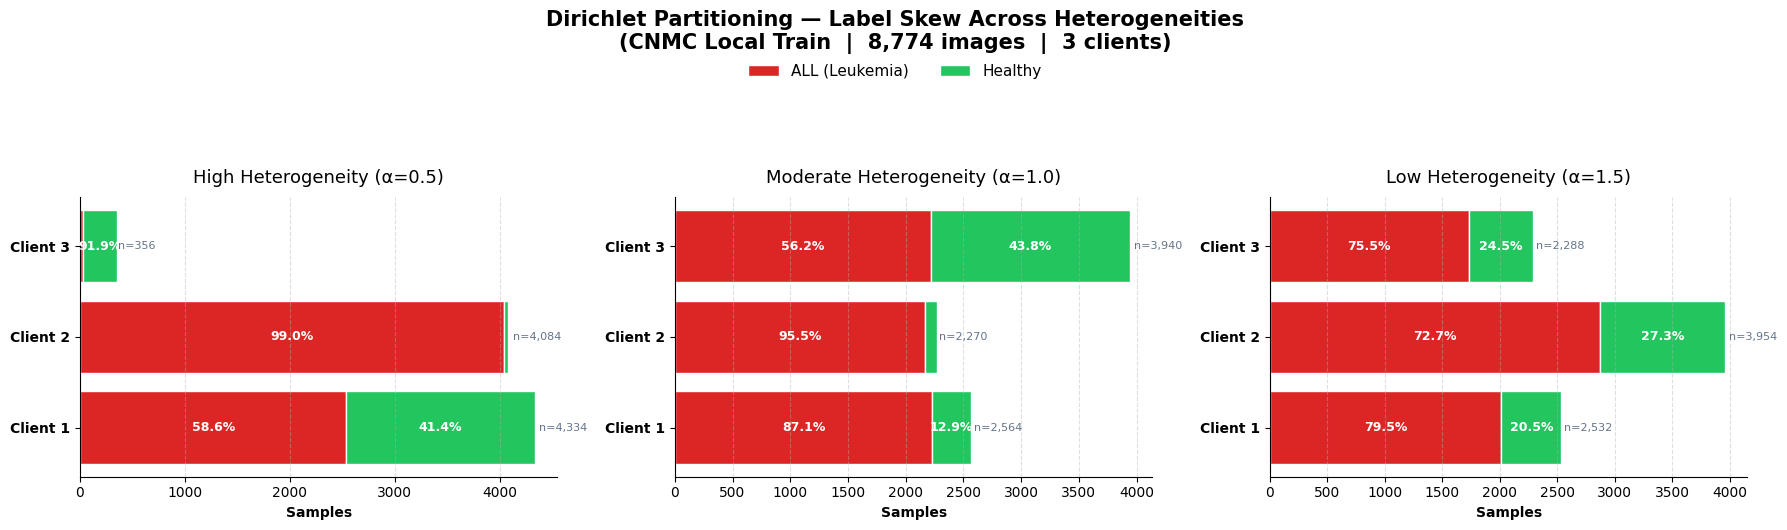

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datasets import Dataset
from flwr_datasets.partitioner import DirichletPartitioner

# ── ✏️  Dataset path (update if running locally) ────────────────────────────
DATASET_PATH = "/content/drive/MyDrive/College/FLEX-Med/backend/datasets/cnmc/cnmc_local_train"
# ────────────────────────────────────────────────────────────────────────────
NUM_CLIENTS = 3

# ── Load real labels from folder structure (all/ = 0, hem/ = 1) ─────────────
def load_labels_from_folder(dataset_path: str) -> list:
    """Scan cnmc_local_train subfolders: 'all' → label 0 (Leukemia), 'hem' → label 1 (Healthy)."""
    image_exts = {".jpg", ".jpeg", ".png", ".bmp"}
    class_map  = {"all": 0, "hem": 1}
    labels = []
    base   = Path(dataset_path)
    for class_name, label in class_map.items():
        class_dir = base / class_name
        if not class_dir.exists():
            print(f"[WARN] Class folder not found: {class_dir}")
            continue
        count = sum(1 for f in class_dir.iterdir() if f.suffix.lower() in image_exts)
        labels.extend([label] * count)
        print(f"  {class_name:5s} (label={label}): {count:,} images")
    return labels

print(f"Loading dataset from: {DATASET_PATH}")
labels = load_labels_from_folder(DATASET_PATH)
total  = len(labels)
leu    = labels.count(0)
hlt    = labels.count(1)
print(f"  Total: {total:,}  |  Leukemia: {leu:,} ({leu/total*100:.1f}%)  |  Healthy: {hlt:,} ({hlt/total*100:.1f}%)\n")

hf_dataset = Dataset.from_dict({"label": labels})

# ── Heterogeneity presets ────────────────────────────────────────────────────
heterogeneities = {
    "High Heterogeneity (α=0.5)":     0.5,
    "Moderate Heterogeneity (α=1.0)": 1.0,
    "Low Heterogeneity (α=1.5)":      1.5,
}

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False)
fig.suptitle("Dirichlet Partitioning — Label Skew Across Heterogeneities\n"
             f"(CNMC Local Train  |  {total:,} images  |  {NUM_CLIENTS} clients)",
             fontsize=15, fontweight="bold", y=1.05)

colors       = ["#dc2626", "#22c55e"]   # Red = Leukemia, Green = Healthy
client_names = [f"Client {i+1}" for i in range(NUM_CLIENTS)]

for ax, (title, alpha) in zip(axes, heterogeneities.items()):
    partitioner = DirichletPartitioner(
        num_partitions=NUM_CLIENTS,
        partition_by="label",
        alpha=alpha,
        min_partition_size=100,
        self_balancing=False,
        shuffle=True,
        seed=42,
    )
    partitioner.dataset = hf_dataset

    client_leu, client_hlt = [], []
    for i in range(NUM_CLIENTS):
        partition = partitioner.load_partition(i)
        pl = partition["label"]
        client_leu.append(pl.count(0))
        client_hlt.append(pl.count(1))

    y_pos = np.arange(NUM_CLIENTS)

    is_first = (ax is axes[0])
    ax.barh(y_pos, client_leu, color=colors[0], edgecolor="white",
            label="ALL (Leukemia)" if is_first else "")
    ax.barh(y_pos, client_hlt, left=client_leu, color=colors[1], edgecolor="white",
            label="Healthy" if is_first else "")

    # Percentage annotations inside bars
    for i in range(NUM_CLIENTS):
        total_i = client_leu[i] + client_hlt[i]
        if total_i == 0:
            continue
        l_pct = client_leu[i] / total_i * 100
        h_pct = client_hlt[i] / total_i * 100

        if l_pct > 10:
            ax.text(client_leu[i] / 2, i, f"{l_pct:.1f}%",
                    va="center", ha="center", color="white", fontweight="bold", fontsize=9)
        if h_pct > 10:
            ax.text(client_leu[i] + client_hlt[i] / 2, i, f"{h_pct:.1f}%",
                    va="center", ha="center", color="white", fontweight="bold", fontsize=9)

        # Total count label at the end of each bar
        ax.text(total_i + total_i * 0.01, i, f"n={total_i:,}",
                va="center", ha="left", color="#64748b", fontsize=8)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(client_names, fontweight="bold")
    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel("Samples", fontweight="bold")
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.97), ncol=2, frameon=False, fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

[INFO] Simulation ID : 8
[INFO] Clients       : ['Asiri', 'Delmon', 'Lanka']


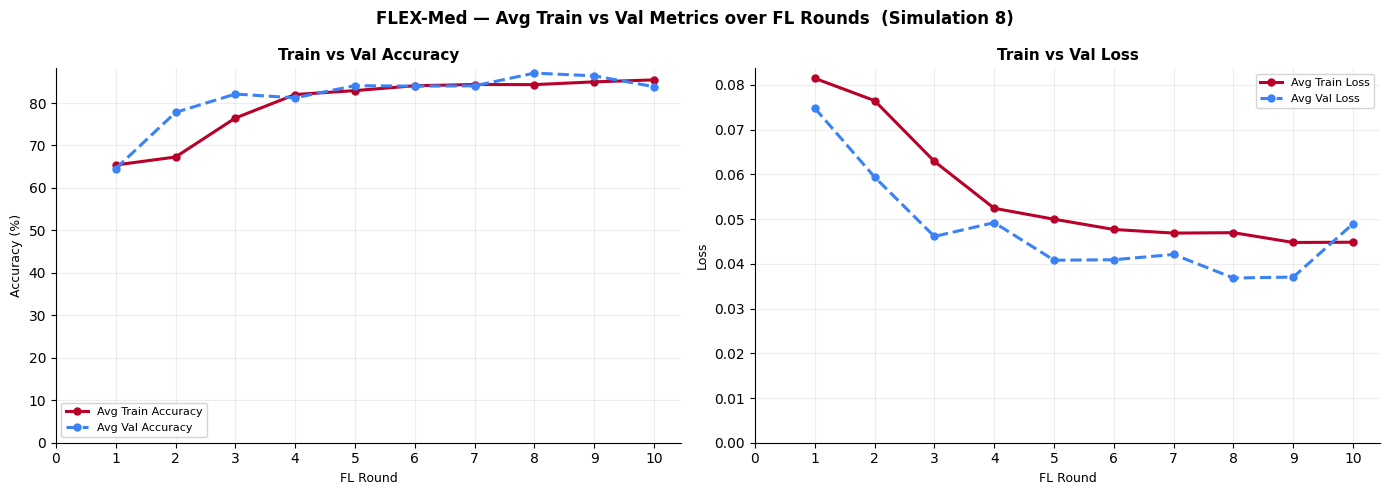

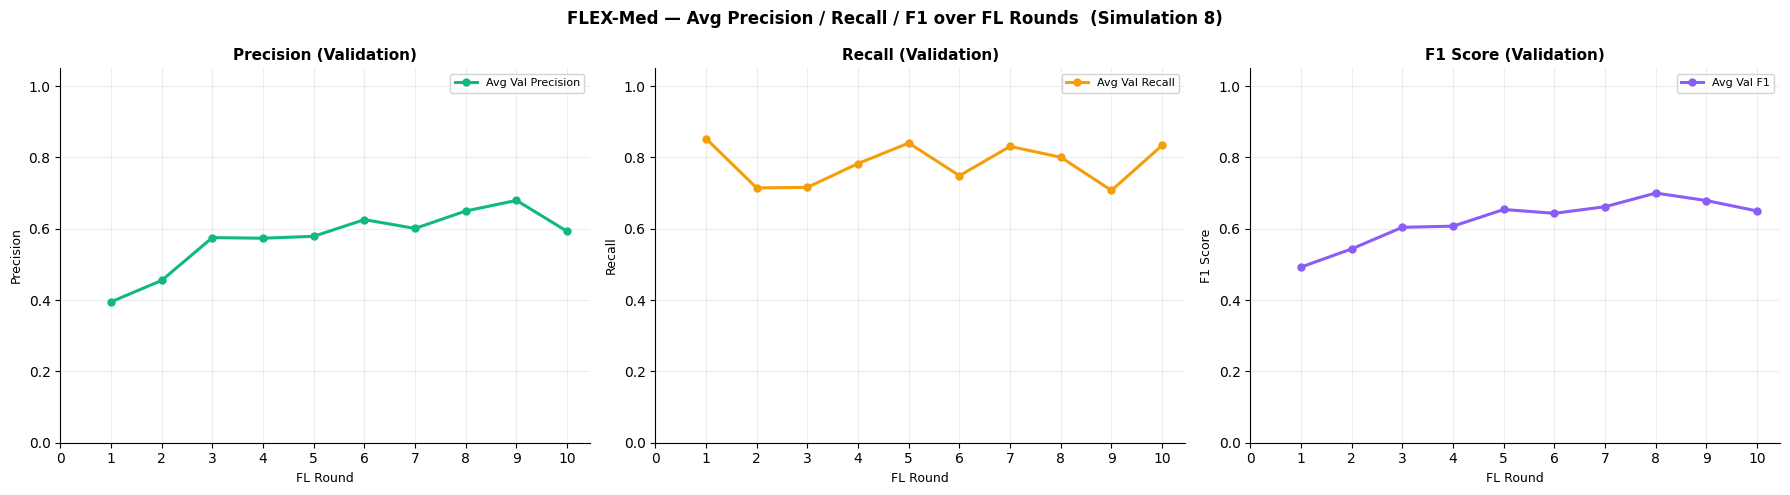

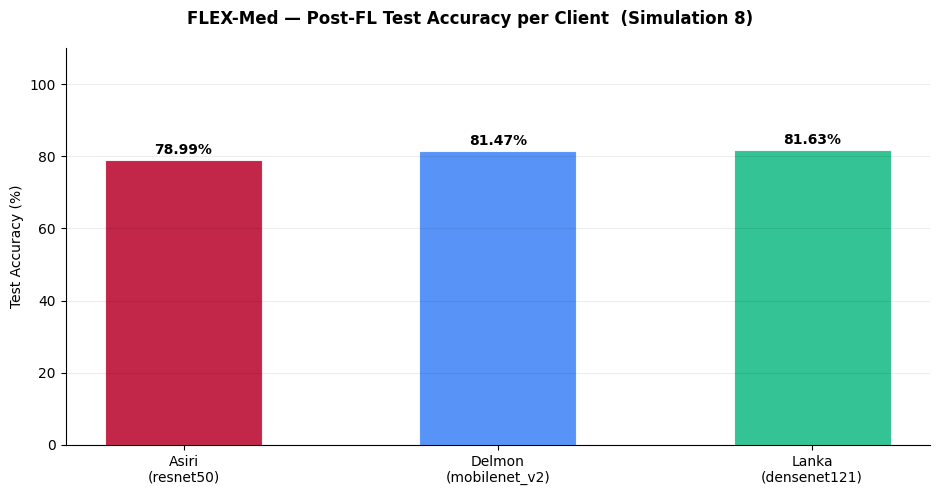

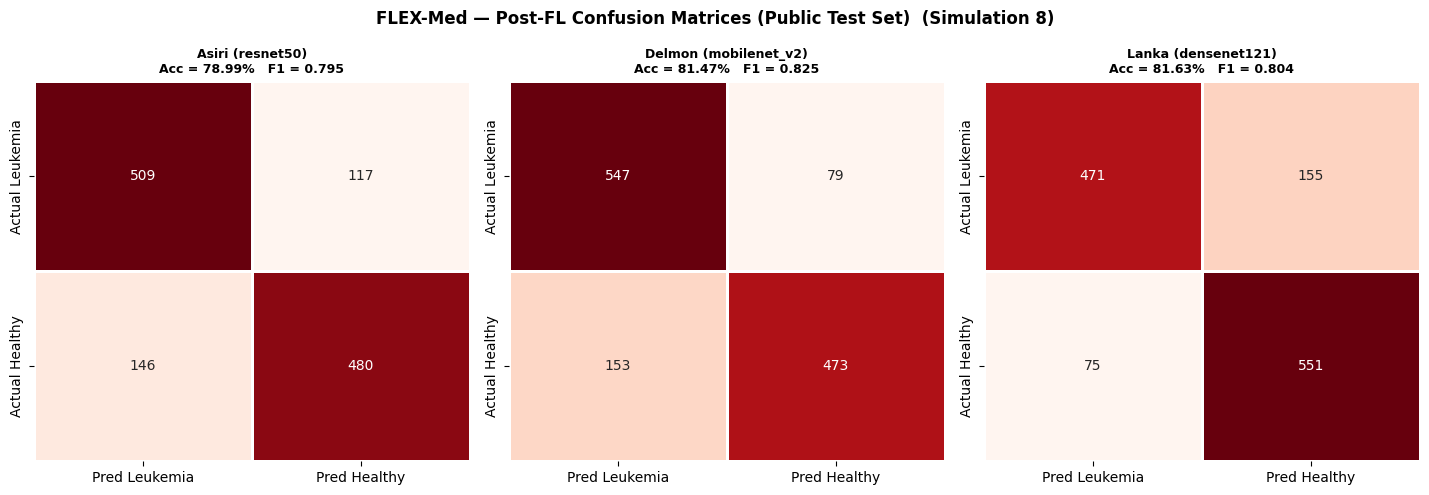

In [7]:
# ==============================================================================
# FLEX-Med — Evaluation Metrics  (6 graphs)
#   1. Line: Avg train accuracy + avg val accuracy over rounds (side-by-side)
#   2. Line: Avg train loss    + avg val loss    over rounds   (side-by-side)
#   3. Line: Avg precision + avg F1 + avg recall over rounds  (side-by-side)
#   4. Bar:  Post-FL test accuracy per client
#   5. Confusion matrix per client                            (side-by-side)
# ==============================================================================

import os, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Optional, List, Dict
from supabase import create_client

# ── ✏️  SET YOUR SIMULATION ID HERE  ────────────────────────────────────────
SIMULATION_ID: Optional[int] = 8      # ← change to None to use the latest
# ────────────────────────────────────────────────────────────────────────────

SUPABASE_URL = os.getenv("SUPABASE_URL", "https://sxwclekerhjlyxehaywu.supabase.co")
SUPABASE_KEY = os.getenv("SUPABASE_KEY", "sb_secret_bDFZ4Q4ATX0q2TmMWibD_A_1t4j6YT2")

PALETTE   = ["#B80028", "#3b82f6", "#10b981", "#f59e0b", "#8b5cf6", "#ec4899"]
AVG_COLOR = "#1e293b"   # dark slate for average line

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

# ── Supabase helpers ─────────────────────────────────────────────────────────
def connect():
    return create_client(SUPABASE_URL, SUPABASE_KEY)

def fetch_data(supabase, simulation_id: Optional[int]) -> tuple:
    """Return (resolved_sim_id, clients_data)."""
    if simulation_id is None:
        r = supabase.from_("fl_simulations").select("id").order("id", desc=True).limit(1).execute()
        if not r.data:
            raise RuntimeError("No simulations found in the database.")
        simulation_id = r.data[0]["id"]

    resp = (
        supabase.from_("client_simulation_metrics")
        .select("client_id, metrics, status, clients(id, client_name, model_type)")
        .eq("simulation_id", simulation_id)
        .order("client_id")
        .execute()
    )
    if not resp.data:
        raise RuntimeError(f"No metrics found for simulation {simulation_id}.")

    clients_data = []
    for row in resp.data:
        info    = row.get("clients") or {}
        metrics = row.get("metrics") or {}
        if isinstance(metrics, str):
            metrics = json.loads(metrics)

        rounds_sorted = sorted(metrics.get("rounds", []), key=lambda r: r.get("round", 0))
        rounds_data   = []
        for r in rounds_sorted:
            tr  = r.get("training")  or {}
            val = r.get("validation") or {}
            rounds_data.append({
                "round":          r.get("round"),
                "train_accuracy": tr.get("train_accuracy"),
                "train_loss":     tr.get("train_loss"),
                "val_loss_train": tr.get("val_loss"),
                "val_accuracy":   val.get("accuracy"),
                "val_loss":       val.get("loss"),
                # ── NEW: per-round precision / recall / f1 ──────────────────
                "val_precision":  val.get("precision"),
                "val_recall":     val.get("recall"),
                "val_f1":         val.get("f1_score") or val.get("f1"),
            })

        clients_data.append({
            "client_name": info.get("client_name", f"Client {row.get('client_id')}"),
            "model_type":  info.get("model_type",  "unknown"),
            "rounds":      rounds_data,
            "post_fl":     metrics.get("global", {}).get("post_fl", {}),
        })
    return simulation_id, clients_data

# ── Average series builder ───────────────────────────────────────────────────
def avg_over_rounds(clients_data: List[Dict], key: str, pct: bool = False):
    """Returns (round_nums, avg_values) averaged across all clients."""
    all_rounds = sorted({r["round"] for c in clients_data for r in c["rounds"] if r.get(key) is not None})
    avgs = []
    for rn in all_rounds:
        vals = [r[key] for c in clients_data for r in c["rounds"] if r["round"] == rn and r.get(key) is not None]
        avgs.append((sum(vals) / len(vals) * (100 if pct else 1)) if vals else None)
    return all_rounds, avgs

# ── Plot helpers ─────────────────────────────────────────────────────────────
def draw_avg_line(ax, rounds, vals, label, color, marker="o", ls="-"):
    y = [v if v is not None else np.nan for v in vals]
    ax.plot(rounds, y, marker=marker, linewidth=2.2, markersize=5,
            color=color, linestyle=ls, label=label)
    if rounds:
        ax.set_xlim(left=0)
        ticks = [0] + list(rounds) if rounds[0] != 0 else list(rounds)
        ax.set_xticks(ticks)
    ax.set_xlabel("FL Round", fontsize=9)
    ax.grid(True, alpha=0.07, color="black")
    ax.legend(fontsize=8, loc="best", framealpha=0.85)

# ── FETCH DATA ───────────────────────────────────────────────────────────────
supabase = connect()
sim_id, clients_data = fetch_data(supabase, SIMULATION_ID)
print(f"[INFO] Simulation ID : {sim_id}")
print(f"[INFO] Clients       : {[c['client_name'] for c in clients_data]}")

# ═══════════════════════════════════════════════════════════════════════════
#  ROW 1: Line graphs — Accuracy  (train vs val)  |  Loss  (train vs val)
# ═══════════════════════════════════════════════════════════════════════════
fig1, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(14, 5))
fig1.suptitle(f"FLEX-Med — Avg Train vs Val Metrics over FL Rounds  (Simulation {sim_id})",
              fontsize=12, fontweight="bold")

# — Accuracy graph —
rounds_tr_acc,  avg_tr_acc  = avg_over_rounds(clients_data, "train_accuracy", pct=True)
rounds_val_acc, avg_val_acc = avg_over_rounds(clients_data, "val_accuracy",   pct=True)

draw_avg_line(ax_acc, rounds_tr_acc,  avg_tr_acc,  "Avg Train Accuracy", PALETTE[0])
draw_avg_line(ax_acc, rounds_val_acc, avg_val_acc, "Avg Val Accuracy",   PALETTE[1], ls="--")
ax_acc.set_title("Train vs Val Accuracy", fontsize=11, fontweight="bold")
ax_acc.set_ylabel("Accuracy (%)", fontsize=9)
ax_acc.set_ylim(bottom=0)

# — Loss graph —
rounds_tr_loss,  avg_tr_loss  = avg_over_rounds(clients_data, "train_loss")
rounds_val_loss, avg_val_loss = avg_over_rounds(clients_data, "val_loss_train")

if not any(v is not None for v in avg_val_loss):
    rounds_val_loss, avg_val_loss = avg_over_rounds(clients_data, "val_loss")

draw_avg_line(ax_loss, rounds_tr_loss,  avg_tr_loss,  "Avg Train Loss", PALETTE[0])
draw_avg_line(ax_loss, rounds_val_loss, avg_val_loss, "Avg Val Loss",   PALETTE[1], ls="--")
ax_loss.set_title("Train vs Val Loss", fontsize=11, fontweight="bold")
ax_loss.set_ylabel("Loss", fontsize=9)
ax_loss.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
#  ROW 2: Line graphs — Precision | Recall | F1   (val, per round)
# ═══════════════════════════════════════════════════════════════════════════
rounds_prec,   avg_prec   = avg_over_rounds(clients_data, "val_precision")
rounds_recall, avg_recall = avg_over_rounds(clients_data, "val_recall")
rounds_f1,     avg_f1     = avg_over_rounds(clients_data, "val_f1")

_any_prf = any(
    any(v is not None for v in vals)
    for vals in [avg_prec, avg_recall, avg_f1]
)

if not _any_prf:
    print("[INFO] Per-round precision / recall / F1 not available in validation block — skipping graph.")
else:
    fig2, (ax_prec, ax_rec, ax_f1) = plt.subplots(1, 3, figsize=(18, 5))
    fig2.suptitle(
        f"FLEX-Med — Avg Precision / Recall / F1 over FL Rounds  (Simulation {sim_id})",
        fontsize=12, fontweight="bold"
    )

    # — Precision —
    draw_avg_line(ax_prec, rounds_prec, avg_prec, "Avg Val Precision", PALETTE[2])
    ax_prec.set_title("Precision (Validation)", fontsize=11, fontweight="bold")
    ax_prec.set_ylabel("Precision", fontsize=9)
    ax_prec.set_ylim(0, 1.05)

    # — Recall —
    draw_avg_line(ax_rec, rounds_recall, avg_recall, "Avg Val Recall", PALETTE[3])
    ax_rec.set_title("Recall (Validation)", fontsize=11, fontweight="bold")
    ax_rec.set_ylabel("Recall", fontsize=9)
    ax_rec.set_ylim(0, 1.05)

    # — F1 —
    draw_avg_line(ax_f1, rounds_f1, avg_f1, "Avg Val F1", PALETTE[4])
    ax_f1.set_title("F1 Score (Validation)", fontsize=11, fontweight="bold")
    ax_f1.set_ylabel("F1 Score", fontsize=9)
    ax_f1.set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

# ═══════════════════════════════════════════════════════════════════════════
#  ROW 3: Post-FL Bar Chart — Test accuracy per client
# ═══════════════════════════════════════════════════════════════════════════
post_fl_available = [c for c in clients_data if c["post_fl"].get("accuracy") is not None]

if not post_fl_available:
    print("[INFO] Post-FL results not yet available.")
else:
    labels   = [f"{c['client_name']}\n({c['model_type']})" for c in post_fl_available]
    accs_pct = [c["post_fl"]["accuracy"] * 100 for c in post_fl_available]
    colors   = [PALETTE[i % len(PALETTE)] for i in range(len(post_fl_available))]

    fig3, ax_bar = plt.subplots(figsize=(max(6, 2.5 * len(post_fl_available) + 2), 5))
    fig3.suptitle(f"FLEX-Med — Post-FL Test Accuracy per Client  (Simulation {sim_id})",
                  fontsize=12, fontweight="bold")

    bars = ax_bar.bar(labels, accs_pct, color=colors, alpha=0.85, width=0.5, edgecolor="white", linewidth=0.8)
    for bar, acc in zip(bars, accs_pct):
        ax_bar.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.8, f"{acc:.2f}%",
                    ha="center", va="bottom", fontsize=10, fontweight="bold")

    ax_bar.set_ylabel("Test Accuracy (%)", fontsize=10)
    ax_bar.set_ylim(0, 110)
    ax_bar.grid(True, axis="y", alpha=0.07, color="black")
    plt.tight_layout()
    plt.show()

# ═══════════════════════════════════════════════════════════════════════════
#  ROW 4: Confusion matrices — side-by-side, one per client
# ═══════════════════════════════════════════════════════════════════════════
cm_available = [c for c in clients_data if c["post_fl"].get("confusion_matrix")]

if not cm_available:
    print("[INFO] No confusion matrix data available (post-FL not yet completed).")
else:
    n   = len(cm_available)
    fig4, axes = plt.subplots(1, n, figsize=(4.8 * n, 5), squeeze=False)
    fig4.suptitle(f"FLEX-Med — Post-FL Confusion Matrices (Public Test Set)  (Simulation {sim_id})",
                  fontsize=12, fontweight="bold")

    for c, ax in zip(cm_available, axes[0]):
        raw = c["post_fl"]["confusion_matrix"]
        TP, FP, FN, TN = raw.get("TP", 0), raw.get("FP", 0), raw.get("FN", 0), raw.get("TN", 0)
        cm_arr = np.array([[TP, FN],
                           [FP, TN]])

        sns.heatmap(cm_arr, annot=True, fmt="d", cmap="Reds", ax=ax, cbar=False,
                    xticklabels=["Pred Leukemia", "Pred Healthy"],
                    yticklabels=["Actual Leukemia", "Actual Healthy"],
                    linewidths=0.8, linecolor="white")

        acc = c["post_fl"].get("accuracy") or 0
        f1  = c["post_fl"].get("f1_score") or 0
        ax.set_title(
            f"{c['client_name']} ({c['model_type']})\nAcc = {acc:.2%}   F1 = {f1:.3f}",
            fontsize=9, fontweight="bold"
        )

    plt.tight_layout()
    plt.show()
